Loaded shape: (50000, 2)
Sample before:
 one of the other reviewers has mentioned that after watching just 1 oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its ...
Sample after:
 one other reviewers has mentioned that after watching just 1 oz episode you ll be hooked they are right as this exactly what happened with me first thing that struck me about oz was its brutality unfl...


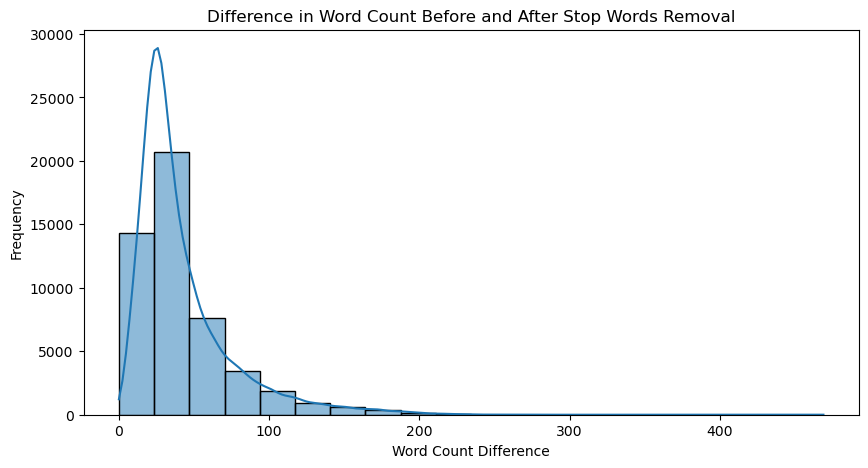

Saved to: stopwords_removed.csv


In [4]:
# IT24100095_StopWordsRemoval.ipynb
# IT24100095 - Stop Words Removal
# Justification: Common words like 'the', 'is', and 'and' are frequent in reviews but carry little sentimental value, adding noise to the feature set.
# Technique: Remove a predefined set of stop words to focus on content-bearing terms.

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt  # Added import for matplotlib
import seaborn as sns  # Added import for seaborn

# Load data from previous step
df = pd.read_csv('../results/outputs/cleaned.csv')
print("Loaded shape:", df.shape)
df.head()

# Define stop words
stop_words = set(['the', 'is', 'and', 'in', 'it', 'of', 'to'])

# Remove stop words
df['review'] = df['review'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))

# EDA: Print sample comparison
print("Sample before:\n", pd.read_csv('../results/outputs/cleaned.csv')['review'].iloc[0][:200] + "...")
print("Sample after:\n", df['review'].iloc[0][:200] + "...")

# Additional EDA Visualization: Word count difference histogram
df['word_count_before'] = pd.read_csv('../results/outputs/cleaned.csv')['review'].apply(lambda x: len(x.split()))
df['word_count_after'] = df['review'].apply(lambda x: len(x.split()))
df['diff'] = df['word_count_before'] - df['word_count_after']

plt.figure(figsize=(10, 5))
sns.histplot(df['diff'], bins=20, kde=True)
plt.title("Difference in Word Count Before and After Stop Words Removal")
plt.xlabel("Word Count Difference")
plt.ylabel("Frequency")
plt.show()

# Interpretation: Sample shows removal of words like 'the' and 'is'; histogram shows positive differences (5-10 words) reflecting stop word elimination.

# Save processed data
df.to_csv('../results/outputs/stopwords_removed.csv', index=False)
print("Saved to: stopwords_removed.csv")